En esta parte tendrás que hacer dos cosas, crear una presentación sobre el titanic de no más de 6 slides, sin incluir portada, con los siguientes mensajes y su apoyo en datos:  
1- El titanic fue un accidente con una tasa de mortalidad alta.  
2- En esa ocasión los datos apoyan que se dio el "Las mujeres y los niños primero", pero...  
3- ... que la clase en la que se viajes tuvo una influencia significativa y podría explicar...  
4- ... las diferencias de tasas de supervivencia entre mujeres y niños.    
5- Además aunque el puerto de embarque parece influir, se podría asumir que lo fue el tipo de pasaje que embarcó en cada uno.  

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
df = pd.read_csv("./data/titanic.csv")

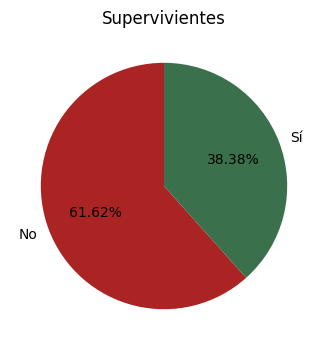

In [ ]:
# 1. Tasa de mortalidad alta:

data = df["alive"].value_counts()

fig,ax = plt.subplots(1,1,figsize = (4,4))

ax.pie(data,
       labels = ["No", "Sí"],
       autopct = '%.2f%%',
       startangle = 90,
       colors=["#AB2424", "#3A704C"])

ax.set_title("Supervivientes");

In [ ]:
# 2. Se dio prioridad a mujeres y niños

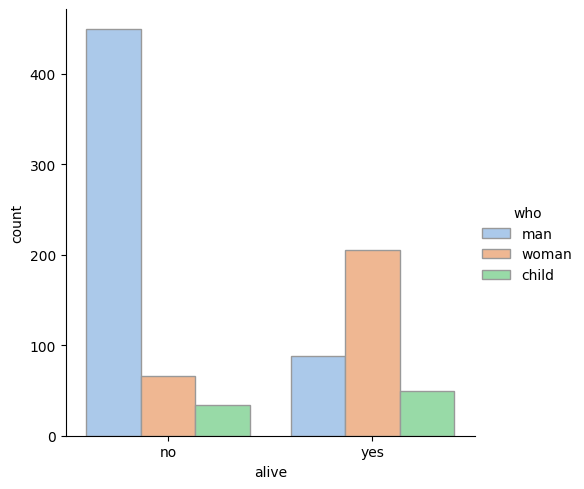

In [ ]:
sns.catplot(x="alive",
            hue="who",
            kind="count",
            edgecolor=".6",
            orient = "V",
            palette = "pastel",
            data=df);

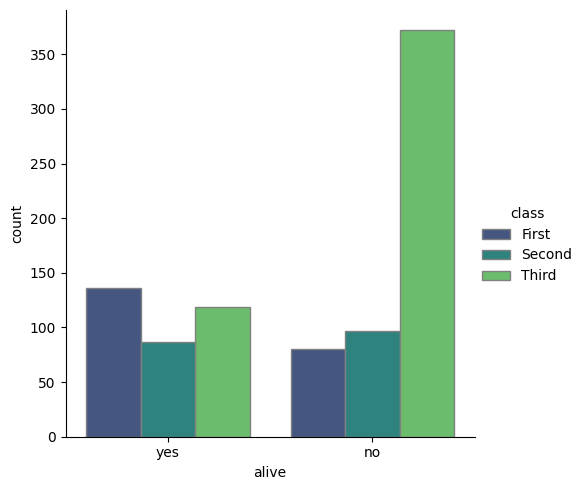

In [ ]:
# 3. Clara prioridad según la clase del pasajero
sns.catplot(x="alive",
            hue="class",
            kind="count",
            edgecolor=".5",
            orient = "V",
            palette="viridis",
            data=df.sort_values("class"));

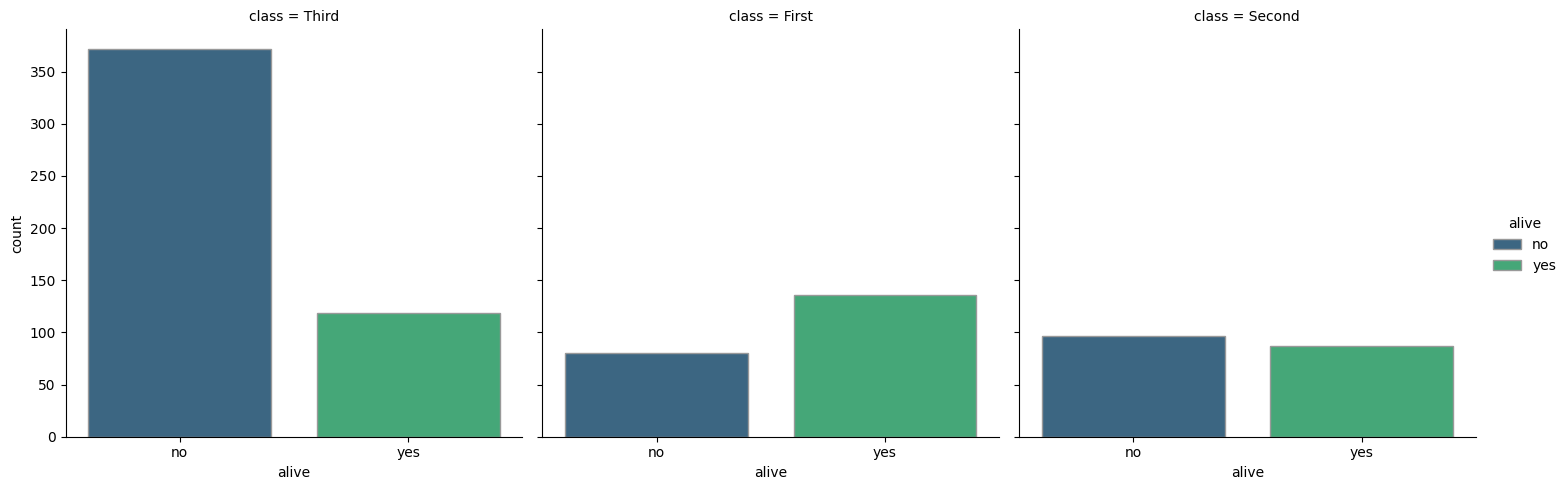

In [ ]:
sns.catplot(x="alive",
            col = "class",
            kind="count",
            edgecolor=".6",
            orient = "V",
            hue = "alive",
            legend= True,
            palette="viridis",
            data=df);

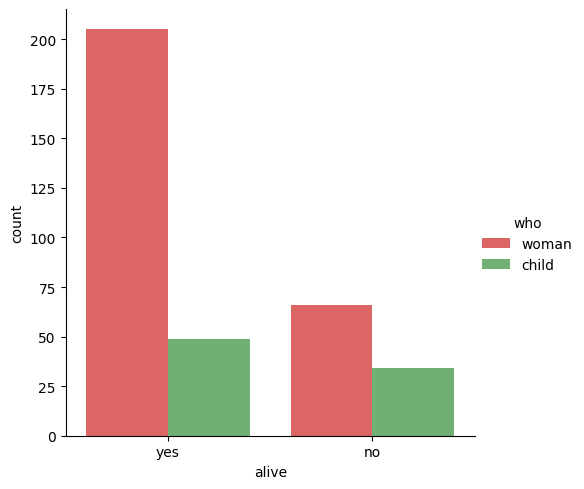

In [ ]:
# 4. Supervivencia entre mujeres y niños
sns.catplot(
    x="alive",
    hue="who",
    kind="count",
    palette=["#EF5350", "#66BB6A"],
    data=df[(df["who"] == "woman") | (df["who"] == "child")]
);

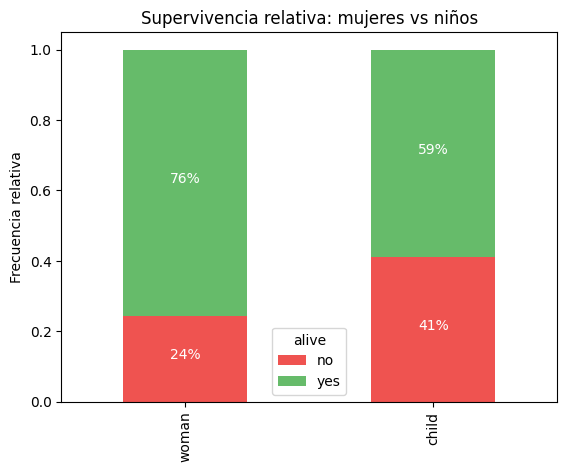

In [ ]:
tabla = pd.crosstab(
    df["who"],
    df["alive"],
    normalize="index"
).loc[["woman", "child"]]

tabla.plot(
    kind="bar",
    stacked=True,
    color=["#EF5350", "#66BB6A"]
)

plt.ylabel("Frecuencia relativa")
plt.xlabel("")
plt.title("Supervivencia relativa: mujeres vs niños")

for i in range(len(tabla)):
    acumulado = 0
    for val in tabla.iloc[i]:
        plt.text(i, acumulado + val/2, f"{val:.0%}", ha="center", color="white")
        acumulado += val

plt.show()

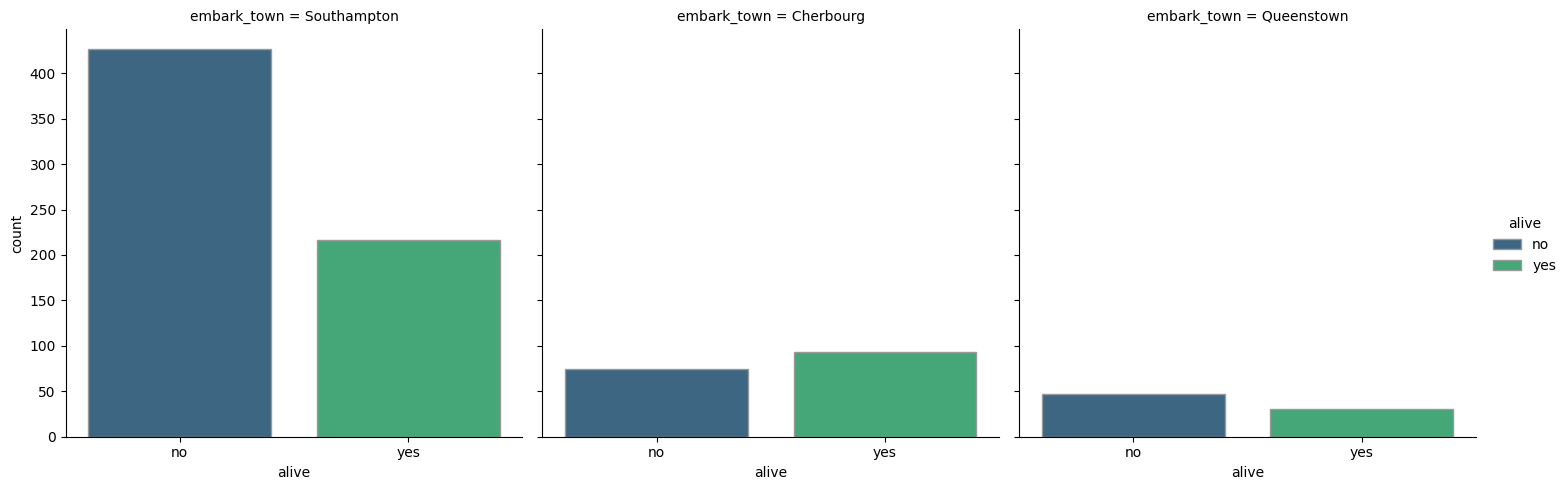

In [ ]:
# 5.A. Puertos de embarque
sns.catplot(x="alive",
            col = "embark_town",
            kind="count",
            edgecolor=".6",
            orient = "V",
            hue = "alive",
            legend= True,
            palette="viridis",
            data=df);

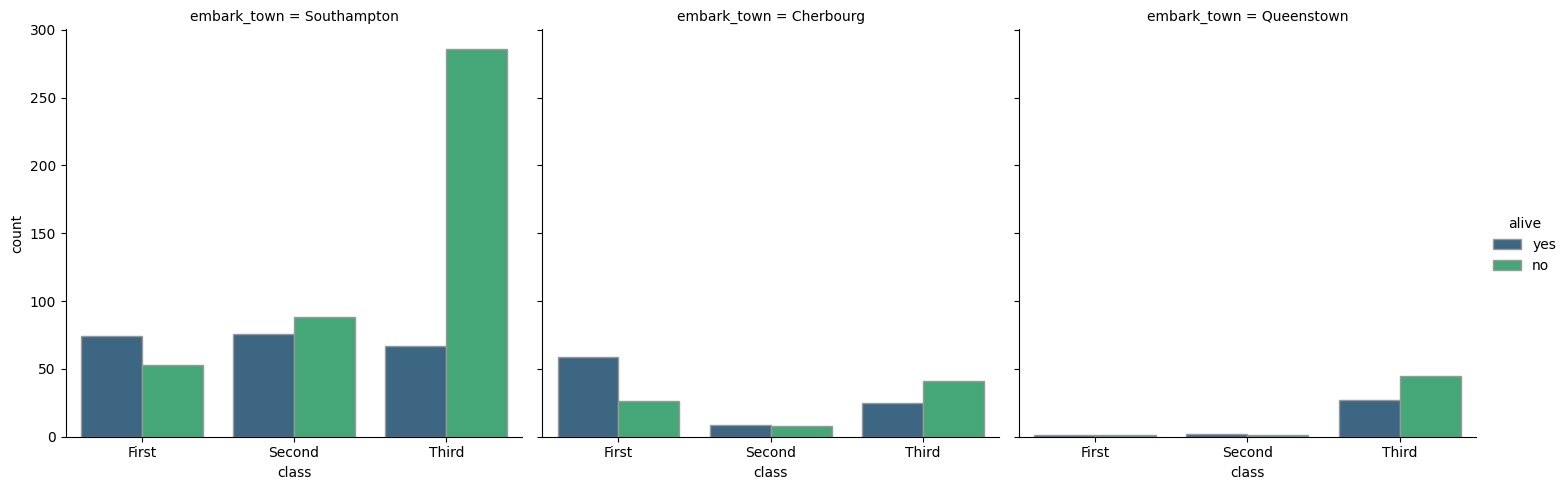

In [ ]:
# 5.B. Puertos de embarque vs clases
sns.catplot(x="class",
            col = "embark_town",
            kind="count",
            edgecolor=".6",
            orient = "V",
            hue = "alive",
            legend= True,
            palette="viridis",
            data=df.sort_values("class"));